# Course Work 1

## Exercise 3

In this exercise, you will implement the the forward and backpropagation algorithms to train a neural network. Please read the instructions in the pdf provided in e-class.

In [198]:
# Here your ID:
import numpy as np
import matplotlib.pyplot as plt #can be reeplaced by other libraries
import pandas as pd
import warnings 
warnings.filterwarnings('ignore')
#is not allowed to use libraries besides the ones here besides reeplacing matplotlib

In [199]:
def standar_norm(X):
    X_mean = np.mean(X, axis=0)
    X_std = np.std(X, axis=0)
    X_norm = (X - X_mean) / X_std
    return X_norm

def verify_columns(df):
    feature_columns = df.columns[:-1]
    return feature_columns

def split_data(df, test_size=0.2, random_state=42):
    np.random.seed(random_state)
    indices = df.index.to_numpy()
    np.random.shuffle(indices)

    n_test = int(len(indices) * test_size)
    test_indices = indices[:n_test]
    train_indices = indices[n_test:]

    df_train = df.loc[train_indices].reset_index(drop=True)
    df_test = df.loc[test_indices].reset_index(drop=True)
    return df_train, df_test

def read_csv(filename):
    df = pd.read_csv(filename)
    return df


In [200]:
def identity(x):
    return x

def identity_derivative(x):
    return np.ones_like(x)

def sigmoid(x):
    x = np.clip(x, -500, 500)
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def mse_loss(y_pred, y_true):
    return np.mean((y_pred - y_true) ** 2)

def root_mean_squared_error(y_pred, y_true):
    return np.sqrt(mse_loss(y_pred, y_true))

In [201]:

def neural_network(X_train, 
            y_train, 
            num_hidden_layers, 
            output_size,
            number_neural_by_layer, 
            num_epochs, 
            learning_rate, 
            activation_funcs,
            activation_derivs,
            lambda_reg=0.01,  # Weight decay parameter
            tau = 1e-6 # umbral: stop when the relative improvement in error
):
    
    if hasattr(y_train, 'values'):
        y_train = y_train.values.reshape(-1, 1)
    else:
        y_train = y_train.reshape(-1, 1)
    input_size = X_train.shape[1]

    if (len(number_neural_by_layer) != num_hidden_layers):
        print("ERROR!!! Number of neurons per layer is not equal to number of hidder layers")
        return
    
    if len(activation_funcs) != (num_hidden_layers + 1):
        print("Activation funcs must be one per layer (hidden + output)")
        return
    
    if len(activation_derivs) != (num_hidden_layers + 1):
        print("Activation derivatives must be one per layer (hidden + output)")
        return 

    layer_sizes = [input_size] + number_neural_by_layer + [output_size]
    
    weight = []
    bias = []
    for i in range(len(layer_sizes)-1):
        w = np.random.randn(layer_sizes[i], layer_sizes[i+1]) * 0.01
        b = np.zeros((1, layer_sizes[i + 1]))
        weight.append(w)
        bias.append(b)

    loss = []
    prev_loss = float('inf')
    for epoch in range(num_epochs):
        # Forward pass
        #z[0] = x1*w1 + x2*w2 + ... + x7*w7 + b
        A = X_train
        activations = [A]
        z_values = []
        for i in range(len(layer_sizes)-1):
            z = np.dot(A, weight[i]) + bias[i]
            z_values.append(z)
            A = activation_funcs[i](z)
            activations.append(A)

        y_pred = A
        mse_val = mse_loss(y_pred, y_train)
        reg_loss = lambda_reg * sum(np.sum(w**2) for w in weight)
        total_loss = mse_val + reg_loss
        loss.append(total_loss)

        # Print progress
        if epoch % 400 == 0:
            print(f"Epoch {epoch}, Loss: {total_loss:.6f}")

        if abs(prev_loss - total_loss) / (prev_loss + 1e-8) < tau:
            print(f"Early stop in epoch {epoch}, relative improvement < {tau}")
            break
        prev_loss = total_loss
        
        # Backward pass
        deltas = []
        gradient_loss_respect_actprev = (y_pred - y_train) * activation_derivs[-1](z_values[-1])  # Gradient of the loss function with respect to the previous activation
        deltas.append(gradient_loss_respect_actprev)
        #print(gradient_loss_respect_actprev.shape) # -> shape of D datapoints x 1 neurons

        ## Gradient of the loss function with respect to the weights and biases
        for i in range(len(layer_sizes) - 2, 0, -1):
            delta = np.dot(deltas[0], weight[i].T) * activation_derivs[i-1](z_values[i-1])
            deltas.insert(0, delta)
        
        ## Update weights and biases with gradient descent
        for i in range(len(layer_sizes)-1):
            dW = np.dot(activations[i].T, deltas[i]) + lambda_reg * weight[i]
            db = np.sum(deltas[i], axis=0, keepdims=True)

            weight[i] -= learning_rate * dW
            bias[i] -= learning_rate * db

    return weight, bias, loss

In [202]:
#Get probabilities
def predict(X, weights, biases, functionActivation):
    A = X
    for i in range(len(weights)):
        z = np.dot(A, weights[i]) + biases[i]
        A = functionActivation[i](z)
    return A

def evaluate_model(X_test, y_test, weights, biases, activation_funcs):
    y_pred = predict(X_test, weights, biases, activation_funcs)
    if hasattr(y_test, 'values'):
        y_test = y_test.values.reshape(-1, 1)
    else:
        y_test = y_test.reshape(-1, 1)
    
    rmse = root_mean_squared_error(y_pred, y_test)
    return rmse, y_pred

def plot_loss(loss, title="Loss during training"):
    plt.figure(figsize=(8, 6))
    plt.plot(loss, label='Loss', color='red')
    plt.xlabel("Epoch")
    plt.ylabel("LOSS")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [203]:
df = read_csv('Concrete_Data.csv')
df_train, df_test = split_data(df, test_size=0.3, random_state=42)
df_train, df_val = split_data(df_train, test_size=0.5, random_state=42)

# Normalize the features minus the label column
feature_columns = df.columns
df_train[feature_columns] = standar_norm(df_train[feature_columns])
df_val[feature_columns] = standar_norm(df_val[feature_columns])
df_test[feature_columns] = standar_norm(df_test[feature_columns])

print("Training set shape:", df_train.shape)
print("Validation set shape:", df_val.shape)
print("Test set shape:", df_test.shape)

X_train, y_train = df_train[feature_columns].values, df_train[df.columns[-1]].values
X_val, y_val = df_val[feature_columns].values, df_val[df.columns[-1]].values
X_test, y_test = df_test[feature_columns].values, df_test[df.columns[-1]].values
df_train

Training set shape: (361, 9)
Validation set shape: (360, 9)
Test set shape: (309, 9)


,Cementcomponent1kgInAM3Mixture,BlastFurnaceSlagcomponent2kgInAM3Mixture,FlyAshcomponent3kgInAM3Mixture,Watercomponent4kgInAM3Mixture,Superplasticizercomponent5kgInAM3Mixture,CoarseAggregatecomponent6kgInAM3Mixture,FineAggregatecomponent7kgInAM3Mixture,Ageday,ConcreteCompressiveStrengthMPaMegapascals
0,0.292071,0.859817,-0.848820,-0.631845,0.594417,-0.830266,0.363323,-0.304345,0.604021
1,-1.058848,-0.323420,1.671759,-2.858570,-0.086983,1.059503,0.061978,0.191595,-0.162545
2,1.908800,-0.816788,-0.848820,0.523645,-0.997638,-0.540336,-0.794627,-0.304345,0.520484
3,-1.058848,-0.323420,1.671759,-2.858570,-0.086983,1.059503,0.061978,-0.552315,-1.088369
4,-1.200075,0.883266,0.889722,-0.126318,0.276006,0.317700,-1.091052,-0.304345,-0.611825
...,...,...,...,...,...,...,...,...,...
356,2.396672,-0.816788,-0.848820,-1.893254,3.491958,-1.638675,1.494784,-0.304345,1.287772
357,1.005334,-0.816788,-0.848820,0.234772,-0.997638,-0.151151,-0.153844,-0.747148,-1.280754
358,-0.276637,1.138861,-0.848820,1.077317,-0.997638,0.000344,-1.022938,-0.747148,-1.586786
359,-1.005687,-0.229976,1.820996,-0.787355,0.032421,0.373858,0.230878,0.970929,1.266962



Testing lr=0.001, layers=[4, 2], lambda_reg=0.0001
Epoch 0, Loss: 1.000003
Early stop in epoch 2, relative improvement < 1e-06
Validation RMSE: 1.0000

Testing lr=0.001, layers=[4, 2], lambda_reg=0.001
Epoch 0, Loss: 1.000019
Early stop in epoch 3, relative improvement < 1e-06
Validation RMSE: 1.0000

Testing lr=0.001, layers=[4, 2], lambda_reg=0.01
Epoch 0, Loss: 1.000063
Early stop in epoch 1, relative improvement < 1e-06
Validation RMSE: 1.0000

Testing lr=0.001, layers=[4, 2], lambda_reg=0.1
Epoch 0, Loss: 1.000584
Early stop in epoch 5, relative improvement < 1e-06
Validation RMSE: 1.0000

Testing lr=0.001, layers=[6, 4, 2], lambda_reg=0.0001
Epoch 0, Loss: 1.000062
Early stop in epoch 4, relative improvement < 1e-06
Validation RMSE: 1.0000

Testing lr=0.001, layers=[6, 4, 2], lambda_reg=0.001
Epoch 0, Loss: 1.000038
Early stop in epoch 4, relative improvement < 1e-06
Validation RMSE: 1.0000

Testing lr=0.001, layers=[6, 4, 2], lambda_reg=0.01
Epoch 0, Loss: 1.000116
Early stop i

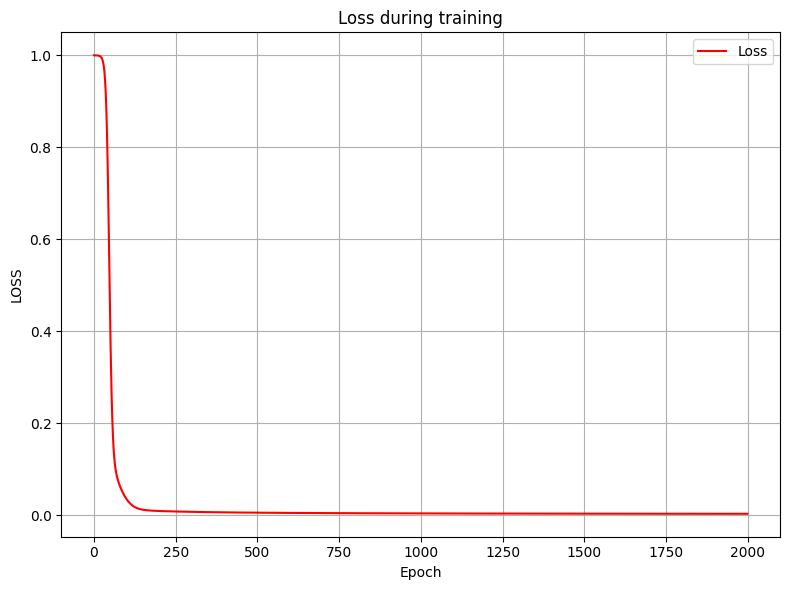

In [204]:
learning_rates = [0.001, 0.0001]
hidden_structures = [[4,2], [6,4,2], [8, 4], [5], [7, 5, 3]]
lambda_regs = [0.0001, 0.001, 0.01, 0.1]

best_rmse = float('inf')
best_params = None

for lr in learning_rates:
    for layers in hidden_structures:
        for lambda_reg in lambda_regs:
            print(f"\nTesting lr={lr}, layers={layers}, lambda_reg={lambda_reg}")
            num_hidden_layers = len(layers)

            activation_funcs = [sigmoid] * num_hidden_layers + [identity]  # output layer is regression
            activation_derivs = [sigmoid_derivative] * num_hidden_layers + [identity_derivative]

            weights, biases, loss = neural_network(
                X_train=X_train,
                y_train=y_train,
                num_hidden_layers=num_hidden_layers,
                output_size=1,
                number_neural_by_layer=layers,
                num_epochs=2000,
                learning_rate=lr,
                activation_funcs=activation_funcs,
                activation_derivs=activation_derivs,
                lambda_reg=lambda_reg
            )

            val_rmse, _ = evaluate_model(X_val, y_val, weights, biases, activation_funcs)

            print(f"Validation RMSE: {val_rmse:.4f}")

            if val_rmse < best_rmse:
                best_rmse = val_rmse
                best_params = (lr, layers, lambda_reg)
                best_weights = weights
                best_biases = biases
                best_loss = loss

print("\nBest validation RMSE:", best_rmse)
print("Best params (lr, layers, lambda_reg):", best_params)

# Plot best training curve
plot_loss(best_loss)


Final training with best hyperparameters...
Learning rate: 0.001, Hidden layers: [5], Lambda: 0.0001
Epoch 0, Loss: 1.000155
Epoch 400, Loss: 0.003822
Epoch 800, Loss: 0.002959
Epoch 1200, Loss: 0.002988
Epoch 1600, Loss: 0.002644

Test RMSE with best hyperparameters: 0.0310


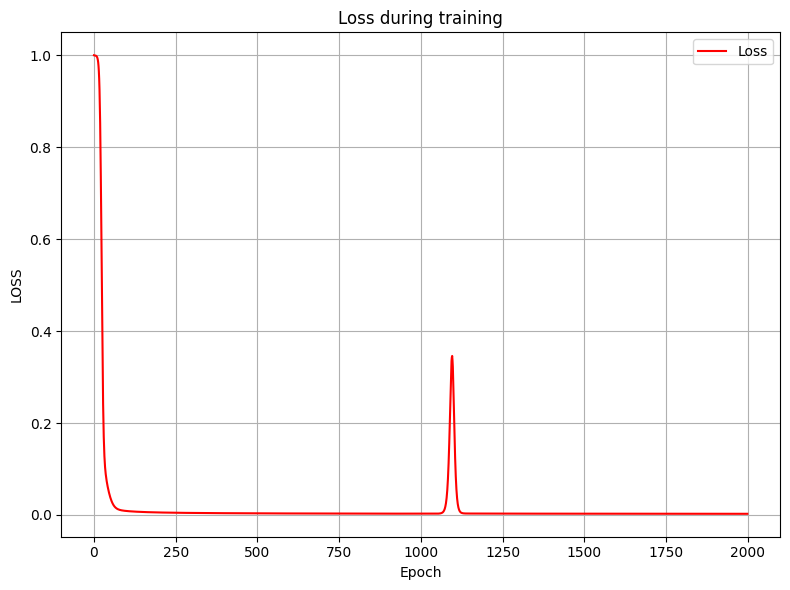

In [205]:
print("\nFinal training with best hyperparameters...")
print(f"Learning rate: {best_params[0]}, Hidden layers: {best_params[1]}, Lambda: {best_params[2]}")
X_final_train = np.vstack((X_train, X_val))
y_final_train = np.hstack((y_train, y_val))

activation_funcs = [sigmoid] * len(best_params[1]) + [identity]
activation_derivs = [sigmoid_derivative] * len(best_params[1]) + [identity_derivative]

weights, biases, loss = neural_network(
    X_train=X_final_train,
    y_train=y_final_train,
    num_hidden_layers=len(best_params[1]),
    output_size=1,
    number_neural_by_layer=best_params[1],
    num_epochs=2000,
    learning_rate=best_params[0],
    activation_funcs=activation_funcs,
    activation_derivs=activation_derivs,
    lambda_reg=best_params[2]
)

final_test_rmse, _ = evaluate_model(X_test, y_test, weights, biases, activation_funcs)
print(f"\nTest RMSE with best hyperparameters: {final_test_rmse:.4f}")
plot_loss(loss)